# 10. Odds, log-odds, odds ratio, Fisher, chi-square i Wald bez `statsmodels`

Ten notebook pokazuje jedną spójną ścieżkę:

1. zaczynamy od **prawdopodobieństwa** `p`, **odds** i **log-odds`,
2. przechodzimy do tabeli 2×2 i **odds ratio**,
3. testujemy tabelę 2×2 testem **Fishera** i **chi-square**,
4. kończymy testem **Walda** i połączeniem z **regresją logistyczną**.

Najważniejsza konwencja w notebooku:

- `p` w pierwszej części oznacza **prawdopodobieństwo zdarzenia**, np. `P(Cancer=Yes)`,
- `p-value` w testach oznacza **poziom istotności / prawdopodobieństwo wyniku przy hipotezie zerowej**.

To są dwie różne rzeczy, mimo że obie często zapisuje się literą `p`.


In [1]:
import math
from math import comb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import hypergeom, chi2, norm, fisher_exact, chi2_contingency

pd.set_option('display.precision', 6)

## 1. Prawdopodobieństwo, odds i log-odds

Prawdopodobieństwo zdarzenia oznaczamy tutaj jako:

$$
0 \le p \le 1
$$

Dla samych wzorów na `odds` i `log-odds` zwykle zakładamy:

$$
0 < p < 1
$$

bo dla $p=0$ lub $p=1$ log-odds są wartościami granicznymi: $-\infty$ albo $+\infty$.

**Odds** to stosunek „sukcesów” do „porażek”:

$$
odds = \frac{p}{1-p}
$$

Odwrotne przejście z odds do prawdopodobieństwa:

$$
p = \frac{odds}{1+odds}
$$

**Log-odds**, czyli **logit**, to logarytm z odds:

$$
logit(p) = \log\left(\frac{p}{1-p}\right)
$$

Intuicja: prawdopodobieństwo `p` żyje w przedziale od 0 do 1, ale `logit(p)` żyje na całej osi rzeczywistej. Dzięki temu w regresji logistycznej możemy modelować log-odds liniowo:

$$
logit(p) = X\beta
$$


### Jak czytać odds zapisane jako `2:3` albo `3:5`?

Zapis **odds = 2:3** oznacza:

- 2 sukcesy,
- 3 porażki,
- razem 5 obserwacji.

To **nie** znaczy, że prawdopodobieństwo wynosi $2/3$.

Jeśli odds zapisujemy jako $a:b$, to:

$$
odds = \frac{a}{b}
$$

ale prawdopodobieństwo sukcesu wynosi:

$$
p = \frac{a}{a+b}
$$

Czyli:

- w odds mianownik to liczba **porażek**,
- w prawdopodobieństwie mianownik to liczba **wszystkich obserwacji**.


In [2]:
odds_examples = pd.DataFrame({
    'odds zapisane jako': ['2:3', '3:5'],
    'sukcesy': [2, 3],
    'porażki': [3, 5],
})

odds_examples['razem'] = odds_examples['sukcesy'] + odds_examples['porażki']
odds_examples['odds jako liczba'] = odds_examples['sukcesy'] / odds_examples['porażki']
odds_examples['p = sukcesy / razem'] = odds_examples['sukcesy'] / odds_examples['razem']
odds_examples['log_odds = log(odds)'] = np.log(odds_examples['odds jako liczba'])

odds_examples


,odds zapisane jako,sukcesy,porażki,razem,odds jako liczba,p = sukcesy / razem,log_odds = log(odds)
0,2:3,2,3,5,0.666667,0.400,-0.405465
1,3:5,3,5,8,0.600000,0.375,-0.510826


Interpretacja dwóch przykładów:

- **odds = 2:3** oznacza $odds=2/3\approx 0.667$, więc $p=2/(2+3)=2/5=0.400$.
- **odds = 3:5** oznacza $odds=3/5=0.600$, więc $p=3/(3+5)=3/8=0.375$.

Dla porównania: gdyby ktoś powiedział **$p=2/3$**, to byłoby coś innego. Wtedy:

$$
odds = \frac{2/3}{1/3}=2
$$

czyli odds wynosiłyby **2:1**, a nie **2:3**.


In [3]:
probabilities = np.array([0.01, 0.05, 0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99])
odds = probabilities / (1 - probabilities)
log_odds = np.log(odds)

pd.DataFrame({
    'p': probabilities,
    'odds = p/(1-p)': odds,
    'log_odds = log(odds)': log_odds,
})

,p,odds = p/(1-p),log_odds = log(odds)
0,0.01,0.010101,-4.595120
1,0.05,0.052632,-2.944439
2,0.10,0.111111,-2.197225
3,0.20,0.250000,-1.386294
4,0.50,1.000000,0.000000
5,0.80,4.000000,1.386294
6,0.90,9.000000,2.197225
7,0.95,19.000000,2.944439
8,0.99,99.000000,4.595120


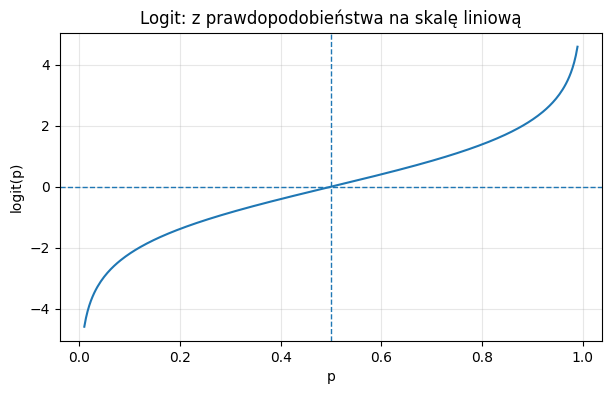

In [4]:
p_grid = np.linspace(0.01, 0.99, 300)
logit_grid = np.log(p_grid / (1 - p_grid))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_grid, logit_grid)
ax.axhline(0, linewidth=1, linestyle='--')
ax.axvline(0.5, linewidth=1, linestyle='--')
ax.set_xlabel('p')
ax.set_ylabel('logit(p)')
ax.set_title('Logit: z prawdopodobieństwa na skalę liniową')
ax.grid(True, alpha=0.3)
plt.show()

## 2. Odds ratio dla tabeli 2×2

Użyjemy klasycznej małej tabeli:

$$
\begin{array}{c|cc}
 & Cancer=Yes & Cancer=No \\
\hline
Mutated=Yes & a & b \\
Mutated=No & c & d
\end{array}
$$

Wtedy:

$$
odds_{mutated} = \frac{a}{b}
$$

$$
odds_{not\ mutated} = \frac{c}{d}
$$

$$
OR = \frac{a/b}{c/d}=\frac{ad}{bc}
$$

oraz:

$$
\log(OR)=\log\left(\frac{ad}{bc}\right)
$$

In [5]:
obs = np.array([[23, 117],
                [ 6, 210]])
counts = pd.DataFrame(obs,
                      index=['Mutated gene: Yes', 'Mutated gene: No'],
                      columns=['Cancer: Yes', 'Cancer: No'])
counts

,Cancer: Yes,Cancer: No
Mutated gene: Yes,23,117
Mutated gene: No,6,210


### W tabeli 2×2: gdzie jest `p`, a gdzie są odds?

W tej tabeli zdarzeniem, czyli „sukcesem”, jest `Cancer=Yes`.

Dla każdej grupy możemy policzyć dwie różne rzeczy:

- **prawdopodobieństwo**: `Cancer=Yes / razem w grupie`,
- **odds**: `Cancer=Yes / Cancer=No`.

To są podobne, ale nie takie same liczby.


In [6]:
a_table, b_table, c_table, d_table = obs.ravel()

group_probability_and_odds = pd.DataFrame({
    'group': ['Mutated=Yes', 'Mutated=No'],
    'Cancer=Yes': [a_table, c_table],
    'Cancer=No': [b_table, d_table],
})

group_probability_and_odds['razem w grupie'] = (
    group_probability_and_odds['Cancer=Yes'] + group_probability_and_odds['Cancer=No']
)
group_probability_and_odds['p = Cancer=Yes / razem'] = (
    group_probability_and_odds['Cancer=Yes'] / group_probability_and_odds['razem w grupie']
)
group_probability_and_odds['odds = Cancer=Yes / Cancer=No'] = (
    group_probability_and_odds['Cancer=Yes'] / group_probability_and_odds['Cancer=No']
)
group_probability_and_odds['log_odds'] = np.log(group_probability_and_odds['odds = Cancer=Yes / Cancer=No'])

group_probability_and_odds


,group,Cancer=Yes,Cancer=No,razem w grupie,p = Cancer=Yes / razem,odds = Cancer=Yes / Cancer=No,log_odds
0,Mutated=Yes,23,117,140,0.164286,0.196581,-1.626680
1,Mutated=No,6,210,216,0.027778,0.028571,-3.555348


Ważna intuicja:

- dla `Mutated=Yes`: $p=23/(23+117)=23/140\approx 0.164$, ale $odds=23/117\approx 0.197$;
- dla `Mutated=No`: $p=6/(6+210)=6/216\approx 0.028$, ale $odds=6/210\approx 0.029$.

Prawdopodobieństwo dzieli przez **całą grupę**, a odds dzielą przez **liczbę porażek / przypadków `No`**.


In [7]:
a, b, c, d = obs.ravel()
odds_mutated = a / b
odds_not_mutated = c / d
odds_ratio = (a*d) / (b*c)
log_odds_ratio = math.log(odds_ratio)

pd.Series({
    'odds_mutated = 23/117': odds_mutated,
    'odds_not_mutated = 6/210': odds_not_mutated,
    'OR = (23*210)/(117*6)': odds_ratio,
    'log(OR)': log_odds_ratio,
})

odds_mutated = 23/117       0.196581
odds_not_mutated = 6/210    0.028571
OR = (23*210)/(117*6)       6.880342
log(OR)                     1.928668
dtype: float64

Interpretacja:

- $OR=1$: brak różnicy odds między grupami,
- $OR>1$: odds są większe w grupie `Mutated=Yes`,
- $OR<1$: odds są mniejsze w grupie `Mutated=Yes`,
- $\log(OR)=0$: brak różnicy,
- dodatni $\log(OR)$: większe odds w pierwszej grupie,
- ujemny $\log(OR)$: mniejsze odds w pierwszej grupie.

## 3. Test Fishera ręcznie

Od tej części pojawia się **p-value**. To nie jest to samo co wcześniejsze `p = P(Cancer=Yes)`.

- wcześniejsze `p` = prawdopodobieństwo zdarzenia,
- `p-value` = prawdopodobieństwo otrzymania wyniku takiego jak obserwowany albo bardziej ekstremalnego, przy założeniu hipotezy zerowej.

Test Fishera zakłada ustalone sumy brzegowe. Pod hipotezą zerową liczba przypadków `Cancer=Yes` w grupie `Mutated=Yes` ma rozkład hipergeometryczny.


In [8]:
row_sums = obs.sum(axis=1)
col_sums = obs.sum(axis=0)
N_total = obs.sum()
K_successes = col_sums[0]
n_draws = row_sums[0]
observed_x = obs[0, 0]

x_min = max(0, n_draws - col_sums[1])
x_max = min(n_draws, K_successes)
xs = np.arange(x_min, x_max + 1)
pmfs = hypergeom.pmf(xs, N_total, K_successes, n_draws)

fisher_table = pd.DataFrame({'x = Cancer Yes in Mutated group': xs, 'probability under H0': pmfs})
fisher_table.loc[fisher_table['x = Cancer Yes in Mutated group'].between(observed_x-3, observed_x+3)]

,x = Cancer Yes in Mutated group,probability under H0
20,20,5.729462e-04
21,21,1.416625e-04
22,22,2.933074e-05
23,23,5.015981e-06
24,24,6.953433e-07
25,25,7.609417e-08
26,26,6.320571e-09


In [9]:
p_observed = hypergeom.pmf(observed_x, N_total, K_successes, n_draws)
p_left = hypergeom.cdf(observed_x, N_total, K_successes, n_draws)
p_right = hypergeom.sf(observed_x - 1, N_total, K_successes, n_draws)
p_two_sided = pmfs[pmfs <= p_observed + 1e-15].sum()

scipy_or, scipy_fisher_p = fisher_exact(obs, alternative='two-sided')

pd.Series({
    'observed_x': observed_x,
    'P(observed table under H0)': p_observed,
    'p_value_left_tail_P(X <= observed)': p_left,
    'p_value_right_tail_P(X >= observed)': p_right,
    'p_value_two_sided_manual': p_two_sided,
    'p_value_two_sided_scipy_fisher': scipy_fisher_p,
})


observed_x                             23.000000
P(observed table under H0)              0.000005
p_value_left_tail_P(X <= observed)      0.999999
p_value_right_tail_P(X >= observed)     0.000006
p_value_two_sided_manual                0.000011
p_value_two_sided_scipy_fisher          0.000011
dtype: float64

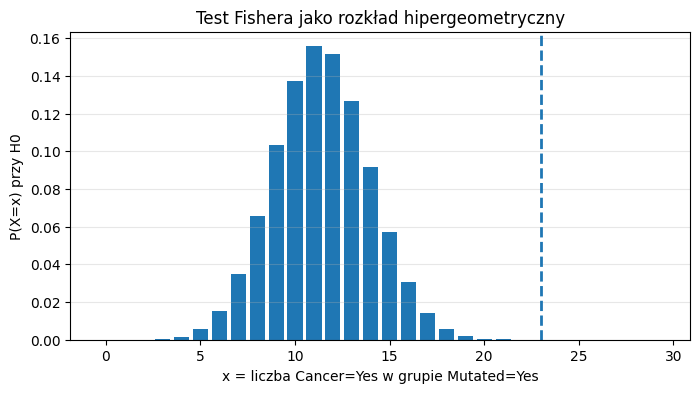

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xs, pmfs)
ax.axvline(observed_x, linestyle='--', linewidth=2)
ax.set_xlabel('x = liczba Cancer=Yes w grupie Mutated=Yes')
ax.set_ylabel('P(X=x) przy H0')
ax.set_title('Test Fishera jako rozkład hipergeometryczny')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

## 4. Test chi-square ręcznie

Test chi-square porównuje liczebności obserwowane z oczekiwanymi przy niezależności.

Liczebność oczekiwana w komórce:

$$
E_{ij}=\frac{row_i\ sum \cdot col_j\ sum}{N}
$$

Statystyka:

$$
\chi^2 = \sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}
$$

Dla tabeli 2×2 stopnie swobody:

$$
df=(2-1)(2-1)=1
$$

In [11]:
expected = np.outer(row_sums, col_sums) / N_total
chi_square_stat = ((obs - expected)**2 / expected).sum()
chi_square_p = chi2.sf(chi_square_stat, df=1)

chi2_scipy, p_scipy, dof_scipy, expected_scipy = chi2_contingency(obs, correction=False)

pd.DataFrame(expected, index=counts.index, columns=counts.columns)

,Cancer: Yes,Cancer: No
Mutated gene: Yes,11.404494,128.595506
Mutated gene: No,17.595506,198.404494


In [12]:
pd.Series({
    'chi_square_manual': chi_square_stat,
    'p_value_manual': chi_square_p,
    'chi_square_scipy_no_yates': chi2_scipy,
    'p_value_scipy_no_yates': p_scipy,
    'df': dof_scipy,
})


chi_square_manual            21.154455
p_value_manual                0.000004
chi_square_scipy_no_yates    21.154455
p_value_scipy_no_yates        0.000004
df                            1.000000
dtype: float64

### Korekta Yatesa

W wielu narzędziach dla tabel 2×2 domyślnie może pojawić się korekta ciągłości Yatesa. Wtedy zamiast $|O-E|$ używa się $|O-E|-0.5$.

W notebooku główny rachunek pokazujemy bez korekty, bo dydaktycznie łatwiej zobaczyć zwykłą konstrukcję testu chi-square.

In [13]:
yates_adjusted_abs_diff = np.maximum(0, np.abs(obs - expected) - 0.5)
yates_stat = ((yates_adjusted_abs_diff**2) / expected).sum()
yates_p = chi2.sf(yates_stat, df=1)
chi2_yates_scipy, p_yates_scipy, _, _ = chi2_contingency(obs, correction=True)

pd.Series({
    'chi_square_yates_manual': yates_stat,
    'p_value_yates_manual': yates_p,
    'chi_square_yates_scipy': chi2_yates_scipy,
    'p_value_yates_scipy': p_yates_scipy,
})


chi_square_yates_manual    19.369422
p_value_yates_manual        0.000011
chi_square_yates_scipy     19.369422
p_value_yates_scipy         0.000011
dtype: float64

## 5. Test Walda dla $\log(OR)$

Przy większych liczebnościach przybliżony błąd standardowy log odds ratio to:

$$
SE(\log(OR)) = \sqrt{\frac{1}{a}+\frac{1}{b}+\frac{1}{c}+\frac{1}{d}}
$$

Statystyka Walda:

$$
z = \frac{\log(OR)}{SE(\log(OR))}
$$

p-value dwustronne:

$$
p = 2P(Z>|z|)
$$

Przedział ufności dla odds ratio:

$$
\exp\left(\log(OR) \pm 1.96\cdot SE\right)
$$

In [14]:
se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
z_wald = log_odds_ratio / se_log_or
p_wald = 2 * norm.sf(abs(z_wald))
ci_log_low = log_odds_ratio - 1.96 * se_log_or
ci_log_high = log_odds_ratio + 1.96 * se_log_or

pd.Series({
    'log_OR': log_odds_ratio,
    'SE_log_OR': se_log_or,
    'z_Wald': z_wald,
    'p_value_Wald': p_wald,
    'OR': odds_ratio,
    'OR_CI_low': math.exp(ci_log_low),
    'OR_CI_high': math.exp(ci_log_high),
})


log_OR           1.928668
SE_log_OR        0.472709
z_Wald           4.080033
p_value_Wald     0.000045
OR               6.880342
OR_CI_low        2.724156
OR_CI_high      17.377531
dtype: float64

## 6. Połączenie z regresją logistyczną

Dla tabeli 2×2 możemy rozwinąć dane do postaci indywidualnych obserwacji i dopasować model:

$$
logit(P(Cancer=Yes)) = \beta_0 + \beta_1 I(Mutated=Yes)
$$

Wtedy:

- $\beta_0$ to log-odds dla grupy referencyjnej `Mutated=No`,
- $\beta_1$ to $\log(OR)$,
- $\exp(\beta_1)$ to $OR$.

Poniżej dopasujemy ten model ręcznie metodą Newtona/IRLS.

In [15]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    z = np.clip(z, -35, 35)
    return 1 / (1 + np.exp(-z))


def loglik_logistic(beta, X, y):
    eta = X @ beta
    return float(np.sum(y * eta - np.logaddexp(0, eta)))


def fit_logistic_irls(X, y, l2=0.0, max_iter=100, tol=1e-10):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, k = X.shape
    beta = np.zeros(k)
    penalty = np.eye(k)
    penalty[0, 0] = 0.0  # nie karzemy interceptu
    converged = False
    for iteration in range(max_iter):
        eta = X @ beta
        p = sigmoid(eta)
        W = p * (1 - p)
        gradient = X.T @ (y - p) - l2 * (penalty @ beta)
        information = (X.T * W) @ X + l2 * penalty
        step = np.linalg.pinv(information) @ gradient
        beta_new = beta + step
        if np.max(np.abs(step)) < tol:
            beta = beta_new
            converged = True
            break
        beta = beta_new
    eta = X @ beta
    p = sigmoid(eta)
    W = p * (1 - p)
    information = (X.T * W) @ X + l2 * penalty
    cov_beta = np.linalg.pinv(information)
    se_beta = np.sqrt(np.diag(cov_beta))
    ll = loglik_logistic(beta, X, y)
    return {
        'beta': beta,
        'se': se_beta,
        'cov': cov_beta,
        'll': ll,
        'converged': converged,
        'iterations': iteration + 1,
        'p_hat': p,
    }


def expand_2x2_counts(a, b, c, d):
    # Mutated=1: a cancer cases, b non-cases; Mutated=0: c cancer cases, d non-cases.
    rows = []
    rows += [{'mutated': 1, 'cancer': 1}] * int(a)
    rows += [{'mutated': 1, 'cancer': 0}] * int(b)
    rows += [{'mutated': 0, 'cancer': 1}] * int(c)
    rows += [{'mutated': 0, 'cancer': 0}] * int(d)
    return pd.DataFrame(rows)

expanded = expand_2x2_counts(a, b, c, d)
X_logit = np.column_stack([np.ones(len(expanded)), expanded['mutated'].to_numpy()])
y_logit = expanded['cancer'].to_numpy()
fit_logit_2x2 = fit_logistic_irls(X_logit, y_logit)
fit_logit_2x2['converged'], fit_logit_2x2['iterations']

(True, 8)

In [16]:
coef_table_logit = pd.DataFrame({
    'coef': fit_logit_2x2['beta'],
    'std_error': fit_logit_2x2['se'],
})
coef_table_logit['z'] = coef_table_logit['coef'] / coef_table_logit['std_error']
coef_table_logit['p_value_Wald'] = 2 * norm.sf(np.abs(coef_table_logit['z']))
coef_table_logit.index = ['intercept_log_odds_Mutated_No', 'log_OR_Mutated_Yes_vs_No']
coef_table_logit

,coef,std_error,z,p_value_Wald
intercept_log_odds_Mutated_No,-3.555348,0.414039,-8.586981,8.928411e-18
log_OR_Mutated_Yes_vs_No,1.928668,0.472709,4.080033,4.502937e-05


In [17]:
pd.Series({
    'beta_1_from_logistic_regression': fit_logit_2x2['beta'][1],
    'manual_log_OR': log_odds_ratio,
    'exp(beta_1)': math.exp(fit_logit_2x2['beta'][1]),
    'manual_OR': odds_ratio,
})

beta_1_from_logistic_regression    1.928668
manual_log_OR                      1.928668
exp(beta_1)                        6.880342
manual_OR                          6.880342
dtype: float64

## 7. Mini-ćwiczenia

### Ćwiczenie A: odds i log-odds z prawdopodobieństwa

Jeśli $p=0.8$, to:

$$
odds=\frac{0.8}{0.2}=4
$$

$$
log(odds)=\log(4)\approx 1.386
$$

### Ćwiczenie A2: prawdopodobieństwo z odds zapisanych jako `a:b`

Jeśli odds wynoszą **2:3**, to:

$$
p=\frac{2}{2+3}=0.4
$$

Jeśli odds wynoszą **3:5**, to:

$$
p=\frac{3}{3+5}=0.375
$$

### Ćwiczenie B: odds ratio

Dla tabeli:

$$
\begin{array}{c|cc}
 & Yes & No \\
\hline
Group A & 8 & 2 \\
Group B & 4 & 6
\end{array}
$$

$$
OR=\frac{8/2}{4/6}=6
$$

albo równoważnie:

$$
OR=\frac{8\cdot 6}{2\cdot 4}=6
$$

### Ćwiczenie C: interpretacja

Jeśli $OR=6$, to odds zdarzenia w `Group A` są 6 razy większe niż odds zdarzenia w `Group B`.

To **nie** znaczy automatycznie, że prawdopodobieństwo jest 6 razy większe.


## 8. Checklista prowadzącego

Po tym notebooku student powinien umieć:

1. Odróżnić `p` jako prawdopodobieństwo od `p-value` w testach statystycznych.
2. Przeliczyć $p \leftrightarrow odds \leftrightarrow log(odds)$.
3. Odczytać odds zapisane jako `a:b`, np. `2:3` albo `3:5`.
4. Policzyć $OR = ad/bc$ dla tabeli 2×2.
5. Wyjaśnić, dlaczego Fisher używa rozkładu hipergeometrycznego.
6. Ręcznie policzyć statystykę chi-square z oczekiwanych liczebności.
7. Zobaczyć różnicę między chi-square bez korekty i z korektą Yatesa.
8. Połączyć współczynnik regresji logistycznej z $\log(OR)$.
